# Load & Review the Data

In [1]:
# Install required packages
!pip install datasets pandas numpy matplotlib seaborn -q
!pip install spacy nltk datasets wordcloud -q
!python -m spacy download en_core_web_sm -q

print("✅ Libraries installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 93.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Libraries installed!


In [2]:
# Import libraries
import pandas as pd
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from pyspark.sql.functions import col, when, year, length
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans

from datasets import load_dataset

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords

# spaCy
import spacy
nlp = spacy.load("en_core_web_sm")

# Get standard English stopwords
STANDARD_STOPWORDS = set(stopwords.words('english'))
print(f"✅ Loaded {len(STANDARD_STOPWORDS)} standard English stopwords")

✅ Loaded 198 standard English stopwords


### Import the Data

In [3]:
# Load from HuggingFace
from datasets import load_dataset

dataset = load_dataset("jhan21/amazon-beauty-reviews-dataset", split="train")

# Convert to pandas DataFrame
df = dataset.to_pandas()

print(f"✅ Loaded {len(df):,} records from HuggingFace")
print(f"   Columns: {list(df.columns)}")

README.md: 0.00B [00:00, ?B/s]

amazon_beauty_reviews_dataset.csv:   0%|          | 0.00/232M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/701528 [00:00<?, ? examples/s]

✅ Loaded 701,528 records from HuggingFace
   Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']


### Verify the Data

In [4]:
# Basic info about your dataset
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Number of rows: {len(df):,}")
print(f"Number of columns: {len(df.columns)}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nData types:")
print(df.dtypes)

DATASET OVERVIEW
Number of rows: 701,528
Number of columns: 10

Column names: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']

Data types:
rating                int64
title                object
text                 object
images               object
asin                 object
parent_asin          object
user_id              object
timestamp            object
helpful_vote          int64
verified_purchase      bool
dtype: object


In [5]:
# Preview first few rows
df.head(10)

,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-05 14:08:48.923,0,True
1,4,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,2020-05-04 18:10:55.070,1,True
2,5,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,2020-05-16 21:41:06.052,2,True
3,1,Synthetic feeling,Felt synthetic,[],B09JS339BZ,B09JS339BZ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2022-01-28 18:13:50.220,0,True
4,5,A+,Love it,[],B08BZ63GMJ,B08BZ63GMJ,AFQLNQNQYFWQZPJQZS6V3NZU4QBQ,2020-12-30 10:02:43.534,0,True
5,4,Pretty Color,The polish was quiet thick and did not apply s...,[{'small_image_url': 'https://images-na.ssl-im...,B00R8DXL44,B00R8DXL44,AGMJ3EMDVL6OWBJF7CA5RGJLXN5A,2020-08-27 22:30:08.138,0,True
6,5,Handy,Great for many tasks. I purchased these for m...,[],B099DRHW5V,B099DRHW5V,AHREXOGQPZDA6354MHH4ETSF3MCQ,2021-09-17 13:31:59.443,0,True
7,3,Meh,These were lightweight and soft but much too s...,[{'small_image_url': 'https://m.media-amazon.c...,B088SZDGXG,B08BBQ29N5,AEYORY2AVPMCPDV57CE337YU5LXA,2021-10-15 05:20:59.292,0,True
8,5,Great for at home use and so easy to use!,This is perfect for my between salon visits. I...,[],B08P2DZB4X,B08P2DZB4X,AFSKPY37N3C43SOI5IEXEK5JSIYA,2021-07-27 13:04:04.559,0,False
9,5,Nice shampoo for the money,I get Keratin treatments at the salon at least...,[],B086QY6T7N,B086QY6T7N,AFSKPY37N3C43SOI5IEXEK5JSIYA,2021-07-18 13:21:51.145,0,False


# Part 1 - Data Quality Assessment

### Check For Missing Values

In [6]:
# Check for missing values
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if len(missing_df) > 0:
    print("\n⚠️ Columns with missing values:")
    print(missing_df.to_string(index=False))
else:
    print("\n✅ No missing values found!")

print(f"\nTotal cells: {df.size:,}")
print(f"Missing cells: {df.isnull().sum().sum():,}")
print(f"Completeness: {(1 - df.isnull().sum().sum() / df.size) * 100:.2f}%")

MISSING VALUES ANALYSIS

⚠️ Columns with missing values:
Column  Missing Count  Missing %
  text            212       0.03
 title            160       0.02

Total cells: 7,015,280
Missing cells: 372
Completeness: 99.99%


In [7]:
# Display first 10 rows with any missing values
print("\nROWS WITH MISSING VALUES (First 10)")
print("=" * 60)

# Filter for rows where 'text' AND 'title' are null
missing_rows = df[df['text'].isnull() & df['title'].isnull()]

if not missing_rows.empty:
    print(missing_rows.head(10).to_string())
else:
    print("No rows with missing 'text' AND 'title' values found.")


ROWS WITH MISSING VALUES (First 10)
        rating title  text images        asin parent_asin                       user_id                timestamp  helpful_vote  verified_purchase
9078         5  None  None     []  B07RV86B18  B07RV86B18  AGWG6V5GXDLTR3ULS6LX2WV672CQ  2019-11-10 00:38:55.104             0               True
29389        4  None  None     []  B079D6VTX2  B079D6VTX2  AE3SRD3YFD2U32HGTOOJVU7LDRCA  2020-07-19 13:21:56.050             0               True
34286        3  None  None     []  B08GYD2LDY  B08GYD2LDY  AH7VW63QYWWNE6RUZ34SEO2HQ6LA  2022-10-25 22:32:02.457             0               True
34289        3  None  None     []  B09C18HXXJ  B09C18HXXJ  AH7VW63QYWWNE6RUZ34SEO2HQ6LA  2022-10-25 22:22:00.242             0               True
54622        4  None  None     []  B00OQKBNUG  B00OQKBNUG  AFLUDL7AERAAQA64C4KKT5VTD6JA  2021-07-12 18:52:15.895             0               True
63711        5  None  None     []  B078J32XBK  B078J32XBK  AGCDK5KLAWWAAJ4HVR3ZNEUST33A

### Remove Rows with Missing Values

In [8]:
# Remove rows where BOTH 'text' and 'title' are missing
df = df[~(df['text'].isnull() & df['title'].isnull())]

### Check for Duplicate Rows

In [9]:
# Check for duplicate rows
print("=" * 60)
print("DUPLICATE RECORDS ANALYSIS")
print("=" * 60)

duplicates = df.duplicated().sum()
duplicate_pct = (duplicates / len(df) * 100)

print(f"\nTotal rows: {len(df):,}")
print(f"Duplicate rows: {duplicates:,}")
print(f"Duplicate percentage: {duplicate_pct:.2f}%")

if duplicates > 0:
    print("\n⚠️ Sample duplicate rows:")
    print(df[df.duplicated(keep=False)].head())
else:
    print("\n✅ No duplicate rows found!")

DUPLICATE RECORDS ANALYSIS

Total rows: 701,470
Duplicate rows: 7,275
Duplicate percentage: 1.04%

⚠️ Sample duplicate rows:
      rating                  title  \
6565       5             Five Stars   
6566       5             Five Stars   
6713       5  Moisturizing  ur skin   
6714       5  Useful For Showering.   
6715       5  Moisturizing  ur skin   

                                                   text images        asin  \
6565                               Great for the price.     []  B00NT0AR7E   
6566                               Great for the price.     []  B00NT0AR7E   
6713       Very pleasant smell and keeps ur skin Moist.     []  B00WDKPW9O   
6714  Very Useful For Taking A Shower After My Opera...     []  B07VQZPHHF   
6715       Very pleasant smell and keeps ur skin Moist.     []  B00WDKPW9O   

     parent_asin                       user_id                timestamp  \
6565  B00NT0AR7E  AHT2QS6TYOXWKTNWDD63CMGOUZDQ  2015-09-25 22:07:06.000   
6566  B00NT0AR7E  AHT

### Remove Duplicate Rows

In [10]:
# Remove exact duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate rows removed.")
print("New dataset shape:", df.shape)

Duplicate rows removed.
New dataset shape: (694195, 10)


### Check for Outliers

In [11]:
# Identify numeric columns and check for outliers
print("=" * 60)
print("OUTLIER ANALYSIS (Numeric Columns)")
print("=" * 60)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns found: {numeric_cols}")

if len(numeric_cols) > 0:
    for col in numeric_cols[:5]:  # Limit to first 5 numeric columns
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_pct = len(outliers) / len(df) * 100

        print(f"\n📊 {col}:")
        print(f"   Range: {df[col].min():.2f} to {df[col].max():.2f}")
        print(f"   Mean: {df[col].mean():.2f}, Median: {df[col].median():.2f}")
        print(f"   Outliers: {len(outliers):,} ({outlier_pct:.1f}%)")
else:
    print("\nNo numeric columns found for outlier analysis.")

OUTLIER ANALYSIS (Numeric Columns)

Numeric columns found: ['rating', 'helpful_vote']

📊 rating:
   Range: 1.00 to 5.00
   Mean: 3.96, Median: 5.00
   Outliers: 0 (0.0%)

📊 helpful_vote:
   Range: 0.00 to 646.00
   Mean: 0.92, Median: 0.00
   Outliers: 53,794 (7.7%)


# Part 2 - Analyze Low Reviews Using NLP Techniques

Filter Low Ratings

In [12]:
low_df = df[df["rating"] <= 3].copy()

print("Low rating reviews:", len(low_df))
percentage = round((len(low_df) / len(df)) * 100)
print(f"{percentage}%")
print(low_df["rating"].value_counts())


Low rating reviews: 199198
29%
rating
1    100887
3     55711
2     42600
Name: count, dtype: int64


In [13]:
import re

# 1) Build full_text (title + text) on the CLEANED df first (safe)
df["title"] = df["title"].fillna("").astype(str)
df["text"]  = df["text"].fillna("").astype(str)
df["full_text"] = (df["title"].str.strip() + " " + df["text"].str.strip()).str.strip()

In [14]:
# 2) Filter low ratings again (so it includes full_text)
low_df = df[df["rating"] <= 3].copy()

In [16]:
import re
from collections import Counter
from nltk.corpus import stopwords

# 3) Clean text -> create clean_text
def make_clean_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"http\S+|www\.\S+", "", s)     # remove URLs
    s = re.sub(r"[^a-z\s]", " ", s)           # keep letters/spaces
    s = re.sub(r"\s+", " ", s).strip()        # normalize whitespace
    return s

low_df["clean_text"] = low_df["full_text"].apply(make_clean_text)

# =========================
# CUSTOM STOPWORDS (to clean cluster themes)
# =========================
# Start with standard English stopwords
custom_stopwords = set(stopwords.words("english"))

# Domain-specific noise (review filler / non-thematic words)
domain_noise = {
    # Generic review words
    "product","amazon","item","buy","bought",
    "use","used","using",
    "one","would","get","got",
    "like","really","even","also","still",
    "make","made",
    "good","great","just",
    "star","stars",

    # Verb fragments from contractions
    "does","doesn","did","didn","dont","don",

    # HTML artifacts
    "br",

    # High-frequency filler words (from your frequency output)
    "much","first","two","better",
    "little","way","back","came",
    "tried","well","nice","time"
}

# Combine
custom_stopwords = custom_stopwords.union(domain_noise)

print(f"✅ Total custom stopwords: {len(custom_stopwords)}")

# =========================
# WORD FREQUENCY (Low Ratings)
# =========================
filtered_words = [
    word for word in low_df["clean_text"].str.cat(sep=" ").split()
    if word not in custom_stopwords
]

word_freq = Counter(filtered_words)

print("\n📊 TOP 30 MOST COMMON WORDS (Low ratings, stopwords removed)")
print("-" * 60)

for i, (word, count) in enumerate(word_freq.most_common(30), 1):
    print(f"{i:2}. {word:15} {count:,}")

✅ Total custom stopwords: 235

📊 TOP 30 MOST COMMON WORDS (Low ratings, stopwords removed)
------------------------------------------------------------
 1. hair            64,887
 2. work            26,874
 3. money           22,455
 4. color           17,350
 5. quality         15,651
 6. waste           14,917
 7. disappointed    14,475
 8. skin            13,601
 9. small           13,150
10. smell           12,760
11. brush           11,772
12. bad             11,551
13. look            11,337
14. cheap           10,561
15. long            10,529
16. worth           9,908
17. price           9,685
18. hard            9,609
19. ok              9,275
20. could           9,192
21. thin            9,170
22. put             9,114
23. pretty          8,897
24. dry             8,833
25. three           8,537
26. face            8,363
27. recommend       8,330
28. love            8,242
29. received        8,227
30. looks           8,173


Convert to TF-IDF

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

# =========================
# CUSTOM STOPWORDS (to clean cluster themes)
# =========================
# Start with standard English stopwords
custom_stopwords = set(stopwords.words("english"))

# Domain-specific noise (review filler / non-thematic words)
domain_noise = {
    # Generic review words
    "product","amazon","item","buy","bought",
    "use","used","using",
    "one","would","get","got",
    "like","really","even","also","still",
    "make","made",
    "good","great","just",
    "star","stars",

    # Verb fragments from contractions
    "does","doesn","did","didn","dont","don",

    # HTML artifacts
    "br",

    # High-frequency filler words (from your frequency output)
    "much","first","two","better",
    "little","way","back","came",
    "tried","well","nice","time"
}

# Combine
custom_stopwords = custom_stopwords.union(domain_noise)

print(f"✅ Total custom stopwords: {len(custom_stopwords)}")

tfidf = TfidfVectorizer(
    stop_words=list(custom_stopwords),  # <-- convert set to list
    max_df=0.85,
    min_df=5,
    max_features=2000
)

X = tfidf.fit_transform(low_df["clean_text"])
print("✅ TF-IDF shape:", X.shape)

✅ Total custom stopwords: 235
✅ TF-IDF shape: (199198, 2000)


# Part 3 - Statistical Analysis Using KMeans & Visualizations

Using K-Means to Cluster Possible Themes

In [18]:
from sklearn.cluster import KMeans
import numpy as np

k = 6
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# Fit + predict clusters from TF-IDF matrix
low_df["cluster"] = kmeans.fit_predict(X)

# Show top terms per cluster
terms = tfidf.get_feature_names_out()
centroids = kmeans.cluster_centers_

for i in range(k):
    top_idx = np.argsort(centroids[i])[-12:][::-1]
    top_terms = [terms[j] for j in top_idx]
    print(f"\nCluster {i} top terms: {top_terms}")

    # Sample reviews from that cluster
    samples = low_df.loc[low_df["cluster"] == i, "text"].head(3).tolist()
    print("Sample reviews:")
    for s in samples:
        print("-", str(s)[:200].replace("\n", " "), "...")


Cluster 0 top terms: ['hair', 'thin', 'thick', 'human', 'quality', 'color', 'hold', 'brush', 'work', 'long', 'bad', 'dry']
Sample reviews:
- I try to get Keratin treatments every 3 months, but honestly it has been getting costly. So, when I saw this I was excited to try it. I found it difficult to use and almost impossible to get to satura ...
- This halo hair extension is simply put, garbage.  Now, you get what you pay for.  And this is a very cheap version.  The faux hair is very shiny and looks literally like bad barbie hair.  It looks WAY ...
- I purchased this for my shoulder length hair. It's very difficult to use, would be best used on longer hair. It's a bit hard to wind the hair around this iron when it's my length. ...

Cluster 1 top terms: ['money', 'waste', 'worth', 'work', 'horrible', 'save', 'nothing', 'cheap', 'hair', 'terrible', 'total', 'complete']
Sample reviews:
- nothing special  unfortunately i waited too long to return them ....  no results at all  dont waste you

In [19]:
from sklearn.cluster import AgglomerativeClustering

# 1) Cluster the centroids (cluster-of-clusters)
meta_cluster = AgglomerativeClustering(n_clusters=3)
meta_labels = meta_cluster.fit_predict(centroids)

# 2) Print cluster -> meta-theme id mapping
for i, label in enumerate(meta_labels):
    print(f"Original Cluster {i} → Meta Theme {label}")

# 3) Give human-readable names to meta themes
meta_name = {
    0: "Product Failure / Poor Quality",
    1: "Mild Dissatisfaction",
    2: "Expectation / Size Issues"
}

# 4) Map each review's cluster to a meta-theme id, then to a name
cluster_to_meta = {i: meta_labels[i] for i in range(len(meta_labels))}
low_df["meta_theme_id"] = low_df["cluster"].map(cluster_to_meta)
low_df["meta_theme"] = low_df["meta_theme_id"].map(meta_name)

# 5) Quantify
print("\nMeta-theme distribution (%):")
print((low_df["meta_theme"].value_counts(normalize=True) * 100).round(2))

Original Cluster 0 → Meta Theme 0
Original Cluster 1 → Meta Theme 0
Original Cluster 2 → Meta Theme 2
Original Cluster 3 → Meta Theme 0
Original Cluster 4 → Meta Theme 0
Original Cluster 5 → Meta Theme 1

Meta-theme distribution (%):
meta_theme
Product Failure / Poor Quality    95.10
Expectation / Size Issues          2.79
Mild Dissatisfaction               2.11
Name: proportion, dtype: float64


In [20]:
complaint_drivers = {
	"Color Issues": ["color", "shade", "dark", "light", "blonde", "red"],
	"Size Issues": ["small", "large", "size", "smaller", "bigger", "fit"],
	"Quantity Issues": ["quantity", "amount", "less", "half", "empty", "missing"],
	"Smell Issues": ["smell", "odor", "scent", "stinks", "fragrance"],
	"Quality Issues": ["cheap", "broke", "broken", "thin", "cracked"],
	"Performance Issues": ["work", "working", "doesnt", "failed", "leak"]
	}
def detect_drivers(text):
	detected = []
	for driver, keywords in complaint_drivers.items():
		if any(word in text for word in keywords):
			detected.append(driver)
	return detected

low_df["drivers"] = low_df["clean_text"].apply(detect_drivers)

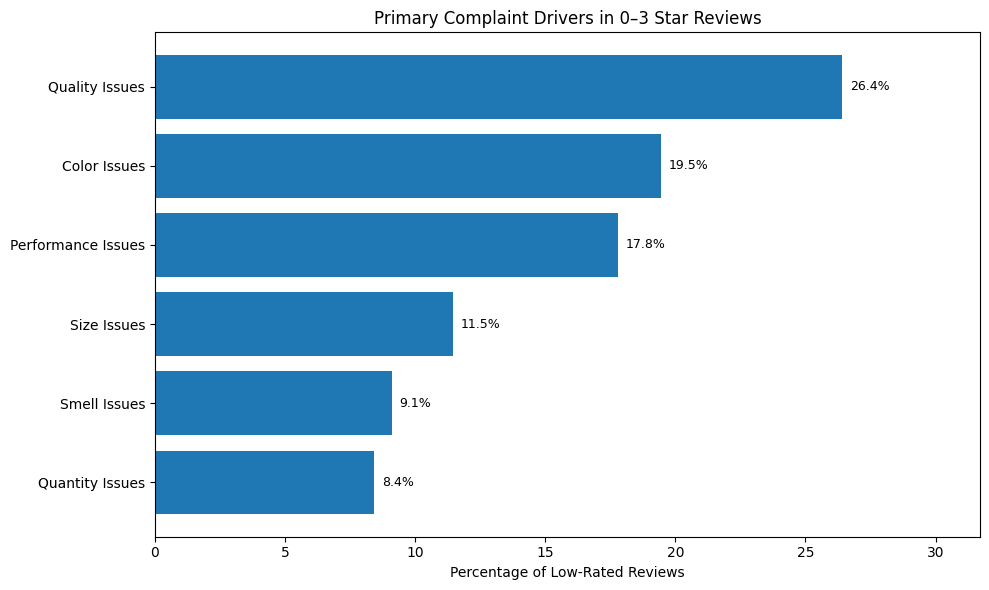

In [22]:
import matplotlib.pyplot as plt

# Create driver_df
driver_counts = low_df["drivers"].explode().value_counts()
driver_df = pd.DataFrame({
    "driver": driver_counts.index,
    "count": driver_counts.values,
    "percentage": (driver_counts.values / len(low_df)) * 100
}).set_index("driver")

plt.figure(figsize=(10, 6))

driver_df_sorted = driver_df.sort_values("percentage")

plt.barh(driver_df_sorted.index, driver_df_sorted["percentage"])
plt.xlabel("Percentage of Low-Rated Reviews")
plt.title("Primary Complaint Drivers in 0–3 Star Reviews")

max_val = driver_df_sorted["percentage"].max()
plt.xlim(0, max_val * 1.2)

for i, v in enumerate(driver_df_sorted["percentage"]):
    plt.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()